# Exploring SSD Alternatives

# GNAV pipeline application on VTTI dataset

With a satellite reference image, we intend to utilize a SfM solution to match ground segments of images to the reference map.
- Inputs: Reference image (satellite), SfM solution (images, points, cameras), selected images (5)
- Output: Correction solutions for translation, rotation, scaling

APPLYING ORIGINAL PIPELINE ON VTTI AIRPORT

In [1]:
import numpy as np
import cv2
import open3d as o3d
import plotly.graph_objects as go
import plotly.io as pio
from scipy.spatial.transform import Rotation as R
from scipy.spatial import cKDTree
import imageio
import pickle
# %matplotlib qt
import matplotlib.pyplot as plt
from matplotlib.path import Path
import time
from scipy.stats import norm, multivariate_normal

from groundNAV_agent_VTTI import *
from colmapParsingUtils import *
from microp_distb_VTTI import *
from distb_plotting_utils_VTTI import *
import pycolmap

# SAVE YOUR WORK
%load_ext autoreload
%autoreload 2
%autosave 180

/home/daniel-choate/miniconda3/envs/py39/lib/python3.9/site-packages/dash/dash.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, parse_version


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Autosaving every 180 seconds


In [2]:
# UPLOAD INPUTS

# CLOSER IMAGES 
# Load in necessary parameters for gNAV agent 
# Define Class Parameters 

images_colm  = "VTTI_data/HIGH/images.txt"
cameras_colm = "VTTI_data/HIGH/cameras.txt"
pts3d_colm = "VTTI_data/HIGH/points3D.txt"

# Local images - folder
im_local = 'VTTI_data/test_images_feb17_2026/' # With 10 local images 


# Load in satellite reference image
sat_ref = "VTTI_data/Satellite/KBCB_partial.jpg" # UPDATED VERSION - ZOOMED IN

In [3]:
# Create class
gnav = gNAV_agent(images_colm, cameras_colm, pts3d_colm, im_local, sat_ref)

# Status check 
# print(gnav.pts3d_c.items)

# Grab raw points and RGB data for scene and reference cloud
scene_pts, rgb_data = gnav.scene_pts, gnav.scene_rgb
ref_pts, ref_rgb = gnav.ref_pts, gnav.ref_rgb

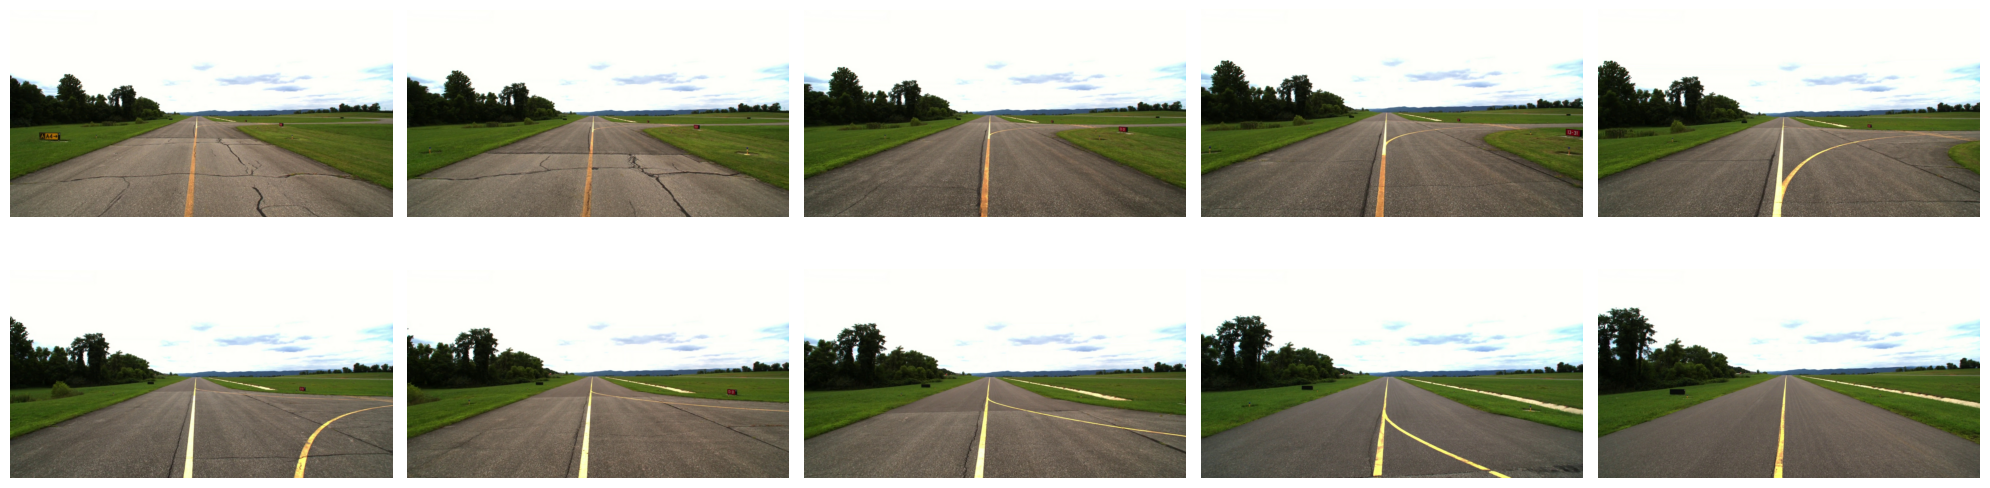

In [4]:
n_imgs = len(gnav.images_dict)
ncols = 5
nrows = math.ceil(n_imgs / ncols)

# Scale figure size: tweak these if you want bigger/smaller
fig_w = 4 * ncols
fig_h = 3 * nrows

plt.figure(figsize=(fig_w, fig_h))

for imnum in range(n_imgs):
    ax = plt.subplot(nrows, ncols, imnum + 1)

    im = gnav.images_dict[imnum]
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

    ax.imshow(im)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# GET POSES 
gnav.grab_poses(gnav.images_c)

## Set Reference Frame to Middle

In [6]:
pts_gnd_idx = np.load("gnd_idx_VTTI_high.npy")
tform_ref_frame = gnav.set_ref_frame(pts_gnd_idx) # ALTER FOR KBCB SPECIFIC
tform_ref_frame_pts = gnav.inv_homog_transform(tform_ref_frame)
print("\nReference frame transformation\n", tform_ref_frame_pts)


Reference frame transformation
 [[ 0.51431895 -0.03090211  0.85704205  0.17398593]
 [ 0.85758321  0.02459256 -0.51375698  0.22011112]
 [-0.00520069  0.99921983  0.03914955  0.90655603]
 [ 0.          0.          0.          1.        ]]


In [7]:
# Transform all points to the new coordinate system 
# Not necessary since we aren't using the cloud, but a good visual check for coord frame
tform_ref_frame_inv = gnav.inv_homog_transform(tform_ref_frame)
origin_ref, scene_pts_ref, scene_vec_ref = gnav.unit_vec_tform(scene_pts, gnav.origin_w, tform_ref_frame_inv)
# print(origin_ref)

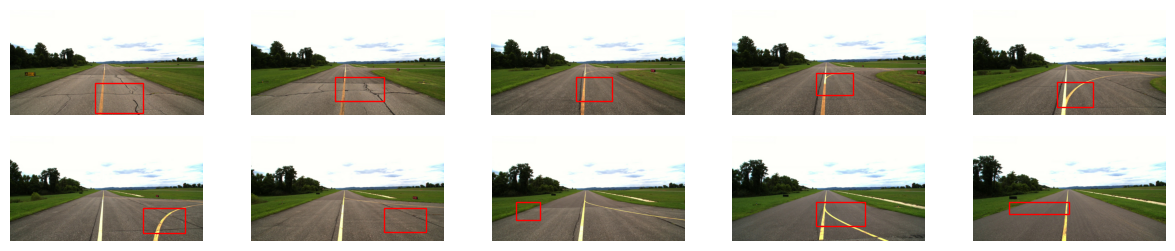

In [8]:
# Load in mosaic params (can be modified)
mosaic_params_KBCB = np.load('mosaic_params_KCBC.npy')

# Grab specified image points from local images 
gnav.grab_image_pts_tot(mosaic_params_KBCB)

plt.figure(figsize=(15,3))
gnav.plot_gnd_pts()

## Projections

In [9]:
## Generate projection of image sections 
# for i in range(gnav.im_num):
# for i in range(1): # TROUBLESHOOTING 1 IMAGE
# Just for the first image for now
for i in range(gnav.im_num):
    # Unit vectors in camera coords 
    pts_vec_c, pts_rgb_gnd = gnav.unit_vec_c(i)
    gnav.im_mosaic[i] = {'rgbc': pts_rgb_gnd}

    # Get transformation matrix that move from camera coords to world coords
    image_id = gnav.im_ids[i]
    homog_w2c, homog_c2w = gnav.get_pose_id(image_id,i)
    # print('Homogeneous transformation from world to camera \n', homog_c2w)
    # print('\n Homogeneous transformation from camera to world \n', homog_w2c)

    # Transform to world coords
    origin_c, pts_loc_w, pts_vec_w = gnav.unit_vec_tform(pts_vec_c, gnav.origin_w, homog_c2w)
    # print('\n New camera frame origin = ', origin_c)
    
    # Get new points 
    ranges, new_pts_w = gnav.pt_range(pts_vec_w, homog_c2w, origin_c, i)
    # print('\nNew Points \n', new_pts_w)

    # Transfer points to reference frame
    __, new_pts_r, pts_vec_r = gnav.unit_vec_tform(new_pts_w, gnav.origin_w, tform_ref_frame_pts)

    # Convert points to grayscale 
    gray_c = gnav.conv_to_gray(gnav.im_mosaic[i]['rgbc'],i)
    # print(gray_c)
    # print(gnav.im_mosaic[i]['rgbc'])

    # Put new points and grayscale colors in image mosaic
    gnav.im_mosaic[i]['pts'] = new_pts_r
    gnav.im_mosaic[i]['color_g'] = gray_c
    
    print("\nDone image ", i)


Done image  0

Done image  1

Done image  2

Done image  3

Done image  4

Done image  5

Done image  6

Done image  7

Done image  8

Done image  9


In [10]:
# PLOTTING THE NEW SCENE MOSAIC

# Use open3d to create point cloud visualization 
# Create visualization 
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Mosaic scene with satellite reference")

# Create axes @ origin
axis_origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=1)

# If we just want to look at specific images
specified_clouds = np.array([0,1,2,3,4,5,7,8,9])

# for i in specified_clouds:
for i in range(gnav.im_num):
    print(i)
    cloud = o3d.geometry.PointCloud()
    cloud.points = o3d.utility.Vector3dVector(gnav.im_mosaic[i]['pts'])
    cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[i]['color_g'])
    vis.add_geometry(cloud)

scene_cloud = o3d.geometry.PointCloud()
scene_cloud.points = o3d.utility.Vector3dVector(scene_pts_ref)
scene_cloud.colors = o3d.utility.Vector3dVector(rgb_data)
vis.add_geometry(scene_cloud)

# Create point cloud for reference cloud (satellite)
ref_cloud = o3d.geometry.PointCloud()
ref_cloud.points = o3d.utility.Vector3dVector(gnav.ref_pts)
ref_cloud.colors = o3d.utility.Vector3dVector(gnav.ref_rgb)

# Add necessary geometries to visualization 
vis.add_geometry(axis_origin)
# vis.add_geometry(ref_cloud)


# Run and destroy visualization 
vis.run()
vis.destroy_window()

0
1


libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 73
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 73
pci id for fd 73: 8086:a7a0, driver iris
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
Using DRI3 for screen 0


2
3
4
5
6
7
8
9


## Ground truth solutions 

In [11]:
# IMPLEMENTING 'TRUTH SOLUTION'
ind_params = np.load("ind_params_KBCB_10IM.npy")
gnav.im_num = len(ind_params) # SETTING IMAGE NUMBER (5)
# print(ind_params)
gnav.ind_params_truth = ind_params
gnav.implement_guess_ind(gnav.ind_params_truth)

In [12]:
# Create visualization
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Image mosaic with reference map (TRUTH)")

gnav.mosaic_w_ref_visualization(vis)

libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 73
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 73
pci id for fd 73: 8086:a7a0, driver iris
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
Using DRI3 for screen 0


# Remaining steps for error modeling pipeline 
- [x] Divide into micropatches
- [x] SSD process for micropatches
- [x] Micropatch distribution analysis
- [x] ERROR DISTB - softmax
    - [x] SSD process for inidividual images
    - [x] Full patch softmax
    - [x] Finding P_i
    - [x] Plot softmax results
- [x] ERROR DISTB - micropatches
    - [x] Blur 2d MP errors
    - [x] Continuous pdf from mixture model
    - [x] Discrete distribution sampling
    - [x] Watershed to GT
    - [x] Plot results
- [ ] Full plot comparison
- [ ] Experiment alternative SSD metrics

### Divide each patch into micropatches

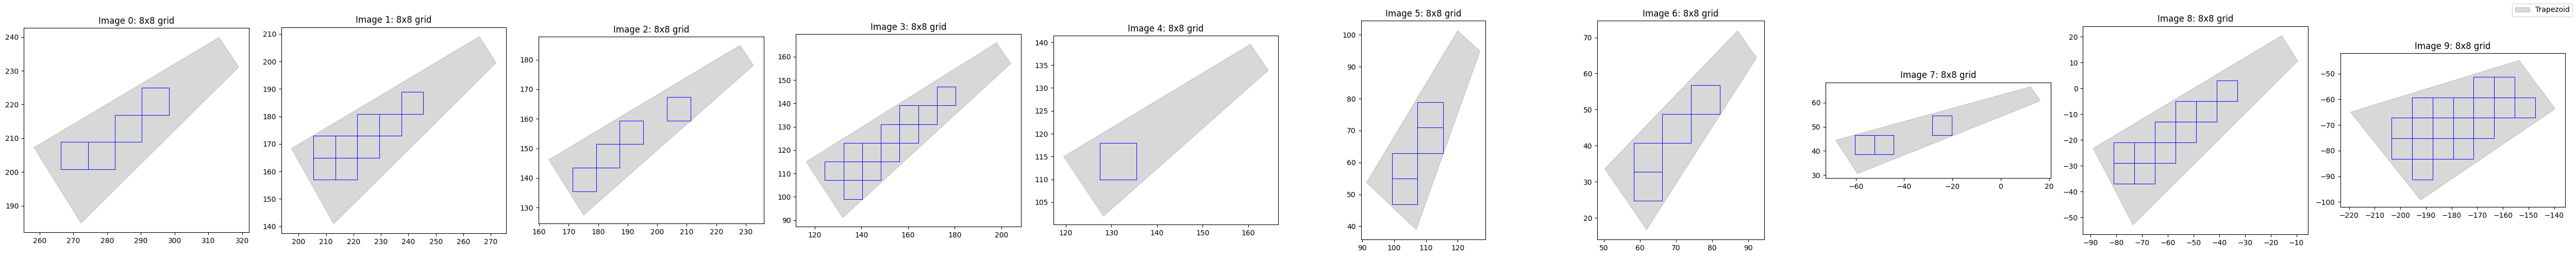

In [13]:
n = 8
micro_ps = gnav.micropatch_division(n)
gnav.micro_ps_local = copy.deepcopy(gnav.micro_ps) # KEEPING ORIGINAL, LOCAL IS WHAT WE EDIT
gnav.plot_traps_w_microps(n)

## Plotting the micropatches

In [14]:
# VISUAL CHECK OF MICROPATCHES
# Check that the points are at least proper

# PLOTTING THE NEW SCENE MOSAIC

# Use open3d to create point cloud visualization 
# Create visualization 
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Mosaic scene with satellite reference")

# Create axes @ origin
axis_origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=10)
# vis.add_geometry(axis_origin)

# Add image patches
# for i in range(len(gnav.images_dict)):
# for i in range(2):
#     cloud = o3d.geometry.PointCloud()
#     cloud.points = o3d.utility.Vector3dVector(gnav.im_pts_best_guess[i]['pts'])
#     cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[i]['color_g'])
#     vis.add_geometry(cloud)


# # Create point cloud for image points
# img_spec = np.array([3])
# for i in img_spec:
#     for j in range(len(micro_ps[i])):
#         # print(j)
#         cloud_micro = o3d.geometry.PointCloud()
#         cloud_micro.points = o3d.utility.Vector3dVector(micro_ps[i][j]['pts'])
#         # cloud_micro.paint_uniform_color([.75, 0.001*j, 0.002*j])
#         cloud_micro.colors = o3d.utility.Vector3dVector(micro_ps[i][j]['color_g'])
#         vis.add_geometry(cloud_micro)



# Create point cloud for reference cloud (satellite)
ref_cloud = o3d.geometry.PointCloud()
ref_cloud.points = o3d.utility.Vector3dVector(gnav.ref_pts)
ref_cloud.colors = o3d.utility.Vector3dVector(gnav.ref_rgb_c)
vis.add_geometry(ref_cloud)

# Run and destroy visualization 
vis.run()
vis.destroy_window()

libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 75
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 75
pci id for fd 75: 8086:a7a0, driver iris
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
Using DRI3 for screen 0


### SSD process for micropatches

In [15]:
ssds_curr_micro = [{} for _ in range(len(gnav.images_dict))]
gnav.ssds_curr_micro = [{} for _ in range(len(gnav.images_dict))]

In [16]:
x = np.ones((3,3))
y = np.zeros((3,3)) + 4
print(x,y,x-y)
print(x-y)

[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]] [[4. 4. 4.]
 [4. 4. 4.]
 [4. 4. 4.]] [[-3. -3. -3.]
 [-3. -3. -3.]
 [-3. -3. -3.]]
[[-3. -3. -3.]
 [-3. -3. -3.]
 [-3. -3. -3.]]


In [17]:
# Loop through images and patches
n_ssd = 5

# for imnum in range(gnav.im_num):
#     for mp in range(len(gnav.micro_ps[imnum])):
#         ssds = gnav.ssd_nxn_micro(n_ssd, imnum, mp)
#         ssds_norm = gnav.ssd_nxn_micro_NORM(n_ssd, imnum, mp)
#         gnav.ssds_curr_micro[imnum][mp] = ssds_norm # CHANGING TO NORMALIZED FROM 'ssds'
#     print(f'Done image {imnum}')

In [18]:
# # Save data as pickle 
# fn = 'KBCB_ssd_8x8_5n_T_NORM_5IMG.pkl'
# with open(fn, 'wb') as f:
#     pickle.dump(gnav.ssds_curr_micro, f)

In [19]:
# Import pickle data structure so we can SAVE SOME TIME
# Load
with open('ssd_trials/KBCB_ssd_8x8_5n_T_NORM_10IMG.pkl', 'rb') as f:
# with open('KBCB_ssd_8x8_5n_T_5IMG.pkl', 'rb') as f:
    ssds_curr_micro_pkl = pickle.load(f)

In [20]:
# # SANITY CHECK 
# for imnum in range(gnav.im_num):
#     for mp in range(len(gnav.micro_ps[imnum])):
#         diff = gnav.ssds_curr_micro[imnum][mp] - ssds_curr_micro_pkl[imnum][mp]
#         print("DIFF", diff)

In [21]:
gnav.ssds_curr_micro = ssds_curr_micro_pkl # Assign to prev calculated values

### Minimum SSD and patch distribution

In [22]:
gnav.distb_vecs = [{} for _ in range(gnav.im_num)]
gnav.distb_pts = [{} for _ in range(gnav.im_num)]

# Grab correction vectors for each micro-patch
n_ssd = 5
for imnum in range(gnav.im_num):
    cor_vecs, points = gnav.dy_from_ssd_micro(n_ssd, imnum)
    gnav.distb_vecs[imnum] = cor_vecs
    gnav.distb_pts[imnum] = points

Done image 0
Done image 1
Done image 2
Done image 3
Done image 4
Done image 5
Done image 6
Done image 7
Done image 8
Done image 9


### Micropatch distribution analysis and plotter class

In [23]:
mpa = microp_distb(gnav, n, n_ssd, t = 1/12) # Alter threshold to t=1/10 if needed
mdb_plotter = microp_distb_plotter(gnav, mpa, n, n_ssd)

In [24]:
# Microp mean and var
mpa.calc_mean_var()

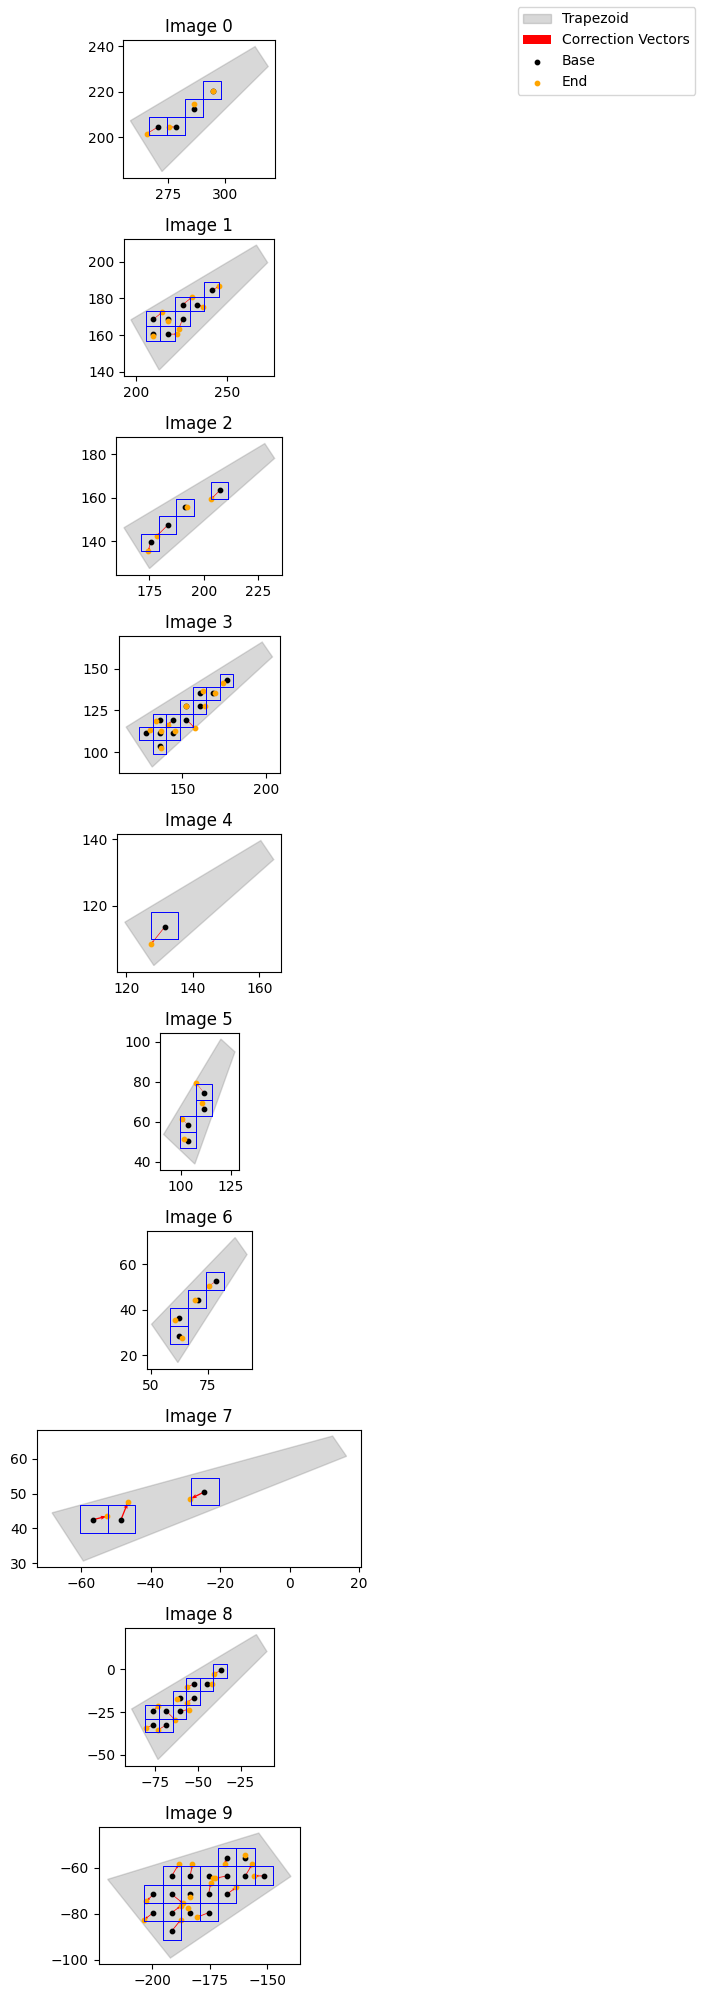

In [25]:
%matplotlib inline
mdb_plotter.plot_microps_w_corVecs()

### Softmax Function for SSD-Based Confidence (FULL PATCH)

Given scores $s_1, s_2, \ldots, s_n$, the softmax function converts them into probabilities:

$$
p_i = \frac{\exp(s_i)}{\sum_j \exp(s_j)}
$$

Softmax: Larger scores receive exponentially more weight.

# LOOKING AT SSDS HERE*******

[700 550 300 200]


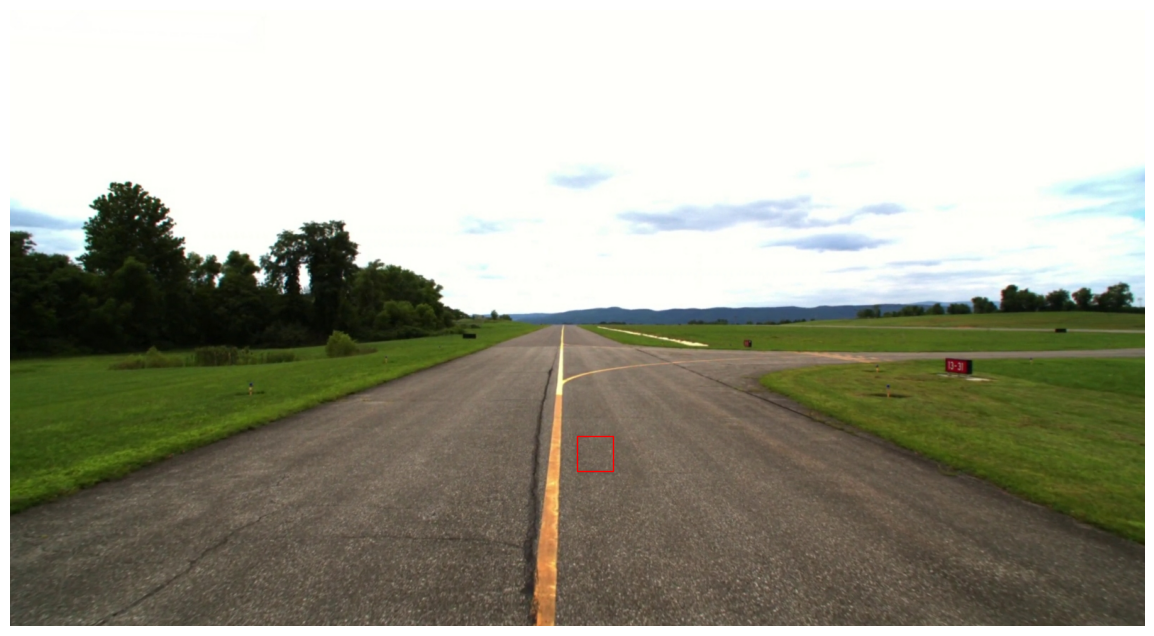

In [26]:
# Finding best case patch 
imnum = 2
print(mosaic_params_KBCB[2])
x, y, w, h = mosaic_params_KBCB[2]
x = 800
y = 600
w = 50
h = 50
pts_loc, pts_rgb = gnav.grab_image_pts(x,y,w,h,imnum)
gnav.plot_rect_im(x,y,w,h,imnum)

In [27]:
print(gnav.im_mosaic[2]['rgbc'].shape)

(60000, 3)


In [28]:
# print(pts_loc)
# print(pts_rgb)
# print(gnav.im_pts_2d[imnum]['rgbc'].shape)
pts_rgb_flat = pts_rgb.reshape(-1,3)
pts_rgb_flat = pts_rgb_flat/255
gray_c = gnav.conv_to_gray(pts_rgb_flat, 2)
print(pts_rgb_flat)
print(pts_rgb_flat.shape)
print(gray_c)
print(gray_c.shape)
# print(pts_rgb/255)
gray_c_m = np.mean(gray_c)
print(gray_c_m)

# print(ref_rgb)

[[0.32156863 0.36862745 0.41568627]
 [0.31372549 0.36078431 0.40784314]
 [0.30588235 0.35294118 0.4       ]
 ...
 [0.3372549  0.38823529 0.45098039]
 [0.34509804 0.39607843 0.45098039]
 [0.34509804 0.39607843 0.45098039]]
(2500, 3)
[[0.35992157 0.35992157 0.35992157]
 [0.35207843 0.35207843 0.35207843]
 [0.34423529 0.34423529 0.34423529]
 ...
 [0.3801451  0.3801451  0.3801451 ]
 [0.38709412 0.38709412 0.38709412]
 [0.38709412 0.38709412 0.38709412]]
(2500, 3)
0.38640129411764707


In [30]:
xmin, xmax = 70, 80
ymin, ymax = 50, 60

pts = gnav.ref_pts

# Create mask
mask = (
    (pts[:, 0] >= xmin) & (pts[:, 0] <= xmax) &
    (pts[:, 1] >= ymin) & (pts[:, 1] <= ymax)
)

highlight_idx = np.where(mask)[0]


colors = gnav.ref_rgb.copy()
colors[highlight_idx] = [1, 0, 0]  # red

In [31]:
# VISUAL CHECK OF MICROPATCHES
# Check that the points are at least proper

# PLOTTING THE NEW SCENE MOSAIC

# Use open3d to create point cloud visualization 
# Create visualization 
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Mosaic scene with satellite reference")

# Create axes @ origin
axis_origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=100)



# Create point cloud for reference cloud (satellite)
cloud = o3d.geometry.PointCloud()
cloud.points = o3d.utility.Vector3dVector(gnav.ref_pts[highlight_idx])
cloud.colors = o3d.utility.Vector3dVector(colors)


# CHECKER
checker = o3d.geometry.PointCloud()
checker.points = o3d.utility.Vector3dVector(gnav.ref_pts[highlight_idx]+np.array([0,0,2]))
checker.colors = o3d.utility.Vector3dVector(gnav.ref_rgb[highlight_idx])



# Create point cloud for reference cloud (satellite)
ref_cloud = o3d.geometry.PointCloud()
ref_cloud.points = o3d.utility.Vector3dVector(gnav.ref_pts)
ref_cloud.colors = o3d.utility.Vector3dVector(gnav.ref_rgb)
vis.add_geometry(ref_cloud)
# vis.add_geometry(cloud)
vis.add_geometry(axis_origin)
vis.add_geometry(checker)

# Run and destroy visualization 
vis.run()
vis.destroy_window()

libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 74
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 74
pci id for fd 74: 8086:a7a0, driver iris
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
Using DRI3 for screen 0


In [32]:
# print(gnav.ref_rgb[highlight_idx])

In [33]:
print(np.mean(gnav.ref_rgb[highlight_idx]))

0.5576082


# TEST

In [75]:
imnum = 0
ssds_TEST = gnav.ssd_nxn_COLOR(n_ssd, imnum)
# print(ssds_TEST)

Number of points used for image 0:  (1173, 3)


In [76]:
%matplotlib qt
mdb_plotter.ssd_surface_plots(ssds_TEST, imnum, n_ssd)#, method='probs')

BEST SHIFT for image 0: -1 1


In [50]:
# COLOR TEST

# PLOTTING THE NEW SCENE MOSAIC

# Use open3d to create point cloud visualization 
# Create visualization 
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Mosaic scene with satellite reference")

# Create axes @ origin
axis_origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=100)


cloud_CHECK = o3d.geometry.PointCloud()
cloud_CHECK.points = o3d.utility.Vector3dVector(gnav.sat_pts_totest)
cloud_CHECK.colors = o3d.utility.Vector3dVector(gnav.sat_rgb_totest)



cloud_CHECK2 = o3d.geometry.PointCloud()
cloud_CHECK2.points = o3d.utility.Vector3dVector(gnav.im_pts_totest + np.array([-5,-5,0]))
cloud_CHECK2.colors = o3d.utility.Vector3dVector(gnav.im_rgb_totest)


scene_cloud = o3d.geometry.PointCloud()
scene_cloud.points = o3d.utility.Vector3dVector(scene_pts_ref)
scene_cloud.colors = o3d.utility.Vector3dVector(rgb_data)
# vis.add_geometry(scene_cloud)

# Create point cloud for reference cloud (satellite)
ref_cloud = o3d.geometry.PointCloud()
ref_cloud.points = o3d.utility.Vector3dVector(gnav.ref_pts)
ref_cloud.colors = o3d.utility.Vector3dVector(gnav.ref_rgb)

# Add necessary geometries to visualization 
# vis.add_geometry(axis_origin)
# vis.add_geometry(ref_cloud)
vis.add_geometry(cloud_CHECK)
vis.add_geometry(cloud_CHECK2)


# Run and destroy visualization 
vis.run()
vis.destroy_window()

libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 74
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
using driver i915 for 74
pci id for fd 74: 8086:a7a0, driver iris
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
libGL: Can't open configuration file /etc/drirc: No such file or directory.
libGL: Can't open configuration file /home/daniel-choate/.drirc: No such file or directory.
Using DRI3 for screen 0


In [77]:
## Through each patch and micro-patch, generate probability distb
mpa.prob_distb_FP = [{} for _ in range(gnav.im_num)]
mpa.ssds_curr_SM = [{} for _ in range(gnav.im_num)]
mpa.ssds_curr_SM_NORM = [{} for _ in range(gnav.im_num)]
mpa.ssds_curr_SM_NORM2 = [{} for _ in range(gnav.im_num)]
mpa.ssds_curr_SM_NEW = [{} for _ in range(gnav.im_num)]
maxp = 0
for imnum in range(gnav.im_num):
    # Grab ssds - FOR FULL PATCH (WE SHOULD SAVE AND REPLUG THIS DATA *****)
    # ssds = gnav.ssd_nxn(n_ssd, imnum)
    # ssds_norm = gnav.ssd_nxn_NORM(n_ssd, imnum)
    ssds_new = gnav.ssd_nxn_COLOR(n_ssd, imnum)
    # mpa.ssds_curr_SM[imnum] = ssds
    mpa.ssds_curr_SM_NEW[imnum] = ssds_new
    # print("SSDS:\n",ssds)
    # print("SSDS with normalized brightness:\n",ssds_new)
    # print(f"Comparison:\n{ssds-ssds_norm}")

Number of points used for image 0:  (1173, 3)
Number of points used for image 1:  (1716, 3)
Number of points used for image 2:  (1143, 3)
Number of points used for image 3:  (1896, 3)
Number of points used for image 4:  (542, 3)
Number of points used for image 5:  (845, 3)
Number of points used for image 6:  (770, 3)
Number of points used for image 7:  (940, 3)
Number of points used for image 8:  (1926, 3)
Number of points used for image 9:  (2149, 3)


#### Full list of SSD trials (all in 'ssd_trials' folder)
Full Images
- KBCB_ssd_curr_SM_5IMG.pkl: full patch regular SSDs using truth - 5 images
- KBCB_ssd_curr_SM_NORM_5IMG.pkl: full patch normalized SSDs (with mean) - 5 images
- KBCB_ssd_curr_SM_NORM_10IMG.pkl: full patch normalized SSDs (with mean) - 10 images
- KBCB_ssd_curr_SM_NORM2_10IMG.pkl: full patch normalized SSDs (with best case) - 10 images **current best**
- KBCB_ssd_curr_SM_NORM_COLOR_10IMG.pkl: full patch normalized SSD (with mean for COLOR) - 10 images 

Micropatches
- KBCB_ssd_8x8_5n_T_5IMG.pkl: micropatch regular SSDs using truth - 5 images
- KBCB_ssd_8x8_5n_T_NORM_5IMG.pkl: micropatch SSDs normalized (with mean) - 5 images
- KBCB_ssd_8x8_5n_T_NORM_10IMG.pkl: micropatch SSDs normalized (with mean) - 10 images

In [79]:
# # Save SSDs for runtime help JUST FOR SAVING 
# # Save data as pickle 
# # fn = 'KBCB_ssd_curr_SM_5IMG.pkl'
# fn = 'ssd_trials/KBCB_ssd_curr_SM_NORM_COLOR_10IMG.pkl'
# with open(fn, 'wb') as f:
#     pickle.dump(mpa.ssds_curr_SM_NEW, f)

In [80]:
# Import pickle data structure so we do not have to run again
# Load
with open('ssd_trials/KBCB_ssd_curr_SM_NORM_10IMG.pkl', 'rb') as f:
    ssds_curr_SM_pkl = pickle.load(f)

# # Sanity check 
# for imnum in range(gnav.im_num):
#     ssds1 = mpa.ssds_curr_SM_NORM[imnum]
#     ssds2 = ssds_curr_SM_pkl[imnum]
#     print(ssds1 - ssds2)

In [81]:
# Set to prev calculated
mpa.ssds_curr_SM = ssds_curr_SM_pkl
gnav.ssds_curr_SM = ssds_curr_SM_pkl

In [88]:
# for i in range(10):
    # print(mpa.ssds_curr_SM[i] - mpa.ssds_curr_SM_NEW[i])
    # print(mpa.ssds_curr_SM_NEW[i])

### SSD Surface Plots

In [87]:
# SSD Verification 
%matplotlib qt
im_check = 4
ssds = mpa.ssds_curr_SM[im_check]
ssds_norm = mpa.ssds_curr_SM_NEW[im_check]
print(ssds-ssds_norm)

mdb_plotter.ssd_surface_plots(ssds, im_check, n_ssd)#, method='probs')
mdb_plotter.ssd_surface_plots(ssds_norm, im_check, n_ssd)#, method='probs')

[[-31.80385384 -25.98981896 -43.97030509 -66.08977189 -70.40707968
  -62.43273065 -56.11768949 -54.49208424 -53.64340022 -50.65661459
  -47.22135684]
 [-43.21044892 -26.83220269 -29.22101164 -51.48935537 -69.21103584
  -68.61576378 -60.46493534 -55.42485259 -54.4843883  -53.16384174
  -49.83699293]
 [-51.86659081 -37.20519735 -23.182653   -34.11390183 -57.54594201
  -70.66285224 -66.19523984 -58.80161055 -55.33818027 -54.02946643
  -52.43326528]
 [-53.26310958 -49.36430709 -31.66369597 -23.1797383  -39.90226473
  -62.78250865 -69.72926718 -63.65084588 -57.52072719 -54.8387665
  -53.83693883]
 [-47.20368    -54.16983096 -45.8371367  -27.5023879  -26.20952334
  -47.42468819 -65.66242027 -67.19960265 -60.72964726 -56.39187192
  -54.79681588]
 [-40.09104114 -50.30248305 -53.65022437 -40.60621549 -24.92247349
  -31.67690192 -53.30475752 -65.82513886 -64.18533011 -58.85061678
  -56.18281714]
 [-35.36972634 -42.9911566  -52.70648012 -51.07250705 -35.41703258
  -25.38995366 -37.78720601 -57.93

# Plotting new intensities 

In [ ]:
# PLOTTING THE NEW SCENE MOSAIC

# Use open3d to create point cloud visualization 
# Create visualization 
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Mosaic scene with satellite reference")

# Create axes @ origin
axis_origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=100)

# If we just want to look at specific images
specified_clouds = np.array([0])

for i in specified_clouds:
    cloud = o3d.geometry.PointCloud()
    cloud.points = o3d.utility.Vector3dVector(gnav.im_pts_best_guess[i]['pts'])
    colors = gnav.im_mosaic[i]['color_g'].copy()
    colors -= np.mean(colors)
    # cloud.colors = o3d.utility.Vector3dVector(colors)
    cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[i]['color_g'])
    vis.add_geometry(cloud)

# cloud_CHECK = o3d.geometry.PointCloud()
# cloud_CHECK.points = o3d.utility.Vector3dVector(gnav.im_pts_best_guess[4]['pts'])#+change)
# cloud_CHECK.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[4]['color_g'])
# vis.add_geometry(cloud_CHECK)

scene_cloud = o3d.geometry.PointCloud()
scene_cloud.points = o3d.utility.Vector3dVector(scene_pts_ref)
scene_cloud.colors = o3d.utility.Vector3dVector(rgb_data)
# vis.add_geometry(scene_cloud)

# Create point cloud for reference cloud (satellite)
ref_cloud = o3d.geometry.PointCloud()
ref_cloud.points = o3d.utility.Vector3dVector(gnav.ref_pts)
color_ref = gnav.ref_rgb.copy()
color_ref -= np.mean(color_ref)
# ref_cloud.colors = o3d.utility.Vector3dVector(color_ref)
ref_cloud.colors = o3d.utility.Vector3dVector(gnav.ref_rgb)

# Add necessary geometries to visualization 
vis.add_geometry(axis_origin)
vis.add_geometry(ref_cloud)


# Run and destroy visualization 
vis.run()
vis.destroy_window()

In [ ]:
print(color_ref)
print(gnav.ref_rgb)

### Full patch softmax

In [ ]:
# Softmax distribution for each FULL patch - generates mpa.prob_distb_FP
mpa.FP_softmax()
# print(mpa.prob_distb_FP[0]['probs'])

In [ ]:
# Surface plot visualization 
%matplotlib qt
# %matplotlib inline
imnum = 3
probs = mpa.prob_distb_FP[imnum]['probs']
mdb_plotter.ssd_surface_plots(probs, imnum, n_ssd, method='probs')

### Finding P_i for FULL PATCH 

In [ ]:
# Set ground truth
p = mpa.im_num
gt = [0,0]
idrow, idcol = gt[0] + n_ssd, gt[1] + n_ssd
Pi_p = np.zeros((p))
cdf = np.zeros((p))
l_total = (n_ssd*2 + 1)**2
print("ID of row and col for P_GT:", idrow, idcol)
# Determine P_i for each image 
for imnum in range(mpa.im_num):
# for imnum in range(1):
    probs = mpa.prob_distb_FP[imnum]['probs']
    pgt = probs[idrow, idcol]
    print(f"\nIMAGE {imnum} ")
    # print("Probabilities\n", probs)
    # print("\nProbability of ground truth:", pgt)
    mask = probs > pgt
    print("\nMask of probabilities:\n",mask)
    probs_p_ind = np.argwhere(probs > pgt)
    # print("\nProbs over PGT (indices):\n", probs_p_ind)
    probs_p = probs[mask]
    l_probs = len(probs_p)
    print(f"\nProbs over PGT, length {l_probs}:\n", probs_p)
    P_i = np.sum(probs_p)
    print("\nP_i:", P_i)
    print("\nCDF:", l_probs/l_total)
    Pi_p[imnum] = P_i
    cdf[imnum] = l_probs / l_total

print("\nFINAL P_i's: \n", Pi_p)

In [ ]:
# PLOT 
Pi_ind_p = np.argsort(Pi_p)
# print(Pi_ind_p)
Pi_p_sorted = Pi_p[Pi_ind_p]
cdf_sorted = cdf[Pi_ind_p]

N = len(Pi_p)
cdf_new = np.arange(0,N)/N
# cdf_new = np.arange(1,N+1)/N
print(cdf_new)
print(Pi_p_sorted)




# ---- Plot ----
plt.figure(figsize=(6, 5))
# OLD
# plt.plot(Pi_p_sorted, cdf_sorted, linewidth=2, label="Empirical CDF of $P_i$")
# plt.scatter(Pi_p_sorted, cdf_sorted, c='blue')
# NEW
plt.plot(Pi_p_sorted, cdf_new, linewidth=2, label="Empirical CDF of $P_i$")
plt.scatter(Pi_p_sorted, cdf_new, c='blue')
plt.plot([0, 1], [0, 1], "--", linewidth=2, label="Reference: $y=x$")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("$P_i$: Predicted CDF")
plt.ylabel("CDF")
plt.title("Empirical CDF of $P_i$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Micropatch Calibration Analysis

In [ ]:
# Micropatch distribution plots
# Plot distribution vectors 
# %matplotlib inline
mdb_plotter.plot_distb_vecs(mpa.distb_vecs, mpa.full_mp_mean_var)

In [ ]:
# Probability distribution generated FOR the full patch BY the micropatch process 
mpa.prob_distb_MP = [{} for i in range(mpa.im_num)]

In [ ]:
def cont_pdf_gblur(x, distb_vecs, sigma_pix):
    assert distb_vecs.ndim == 2 and distb_vecs.shape[1] == 2
    cov = np.eye(2) * (sigma_pix**2)
    vals = [multivariate_normal.pdf(x, mean=mu, cov = cov) for mu in distb_vecs]
    return np.mean(vals)

In [ ]:
# Define variables
n_ssd = 5 # SSD full shift 
sigma_pix = 3 # Gaussian blur param
GT_pos = np.array([0,0]) # Position of ground truth
Pi_p_microp = np.zeros((mpa.im_num)) # eCDF probabilities
step = 1 # Grid size 
steps_TEST = [.05, 1, 25, .5, 1] 
Pi_p_microp_GRID_TEST = []
shifts = np.arange(-n_ssd, n_ssd+step, step) 
print(f'Shifts: {shifts}')
N = len(shifts)


# print(GT_pos.shape)
for imnum in range(mpa.im_num):
    print(f"IMAGE: {imnum}\n")
    distb_vecs_im = mpa.distb_vecs[imnum]
    # LOOP OVER SSD 
    # ssds_prob = np.zeros((2*n_ssd + 1, 2*n_ssd + 1))
    ssds_prob = np.zeros((N,N))
    count = 0
    for i, xshift in enumerate(shifts):
        for j, yshift in enumerate(shifts):
            count +=1
            shift = np.array([xshift, yshift])
            # print("SSD shift:", xshift, yshift)
            p_x = cont_pdf_gblur(shift, distb_vecs_im, sigma_pix)
            # print("P_x:", p_x)
            # ssds_prob[xind,yind] = p_x
            ssds_prob[i,j] = p_x

    # Normalize and place probabilities in dict and 
    # print(f"Discrete probabilites for image {imnum}: \n{ssds_prob}")
    sum_probs = np.sum(ssds_prob)
    # print("SUM of probabilities:", sum_probs)
    norm_probs = ssds_prob / sum_probs
    mpa.prob_distb_MP[imnum]['probs'] = norm_probs
    # print("Normalized probabilities:", norm_probs)
    # print(f"Sum of normalized probs (should be 1): {np.sum(norm_probs)}")

    # Watershed for gt
    ix = np.argmin(np.abs(shifts - GT_pos[0]))
    iy = np.argmin(np.abs(shifts - GT_pos[1]))
    # pgt = norm_probs[n_ssd, n_ssd] # Ground truth probability
    pgt = norm_probs[ix,iy]
    # print(f'Ground truth probability indices: {ix,iy}')
    print(f'Ground truth probability: {pgt}')
    mask = norm_probs >= pgt
    print(f"MASK:\n{mask}")
    probs_over_gt = norm_probs[mask]
    l_probs = len(probs_over_gt)
    print(f"\nProbs over PGT, length {l_probs}:\n", np.round(probs_over_gt,4))
    P_i = np.sum(probs_over_gt)
    print('\nP_i: %.3f' % P_i)
    Pi_p_microp[imnum] = P_i

print(f"\nFINAL P_i's:\n{Pi_p_microp}")
Pi_p_microp_INITIAL = Pi_p_microp


In [ ]:
# Surface plot visualization 
%matplotlib qt
# %matplotlib inline
imnum = 3
# probs = mpa.prob_distb_FP[imnum]['probs']
probs = mpa.prob_distb_MP[imnum]['probs']
mdb_plotter.ssd_surface_plots(probs, imnum, n_ssd, method='probs')

In [ ]:
# PLOT 
N1 = len(Pi_p)
Pi_p_sorted = np.sort(Pi_p)
cdf1 = np.arange(1,N1+1)/N1
cdf1 = np.arange(0,N1)/N1

# SECOND PLOT 
N2 = len(Pi_p_microp_INITIAL)
Pi_p_microp_sorted = np.sort(Pi_p_microp_INITIAL)
cdf2 = np.arange(1,N2+1)/N2
cdf2 = np.arange(0,N2)/N2
print(Pi_p_microp_sorted)
print(f"Micropatch PDF probabilities: \n{np.round(Pi_p_microp_sorted,3)}")
# cdf2 = np.arange(0,N2)/N2

# ---- Plot ----
plt.figure(figsize=(6, 5))
# NEW
plt.plot(Pi_p_sorted, cdf1, linewidth=2, label="eCDF of $P_i$ (Softmax)")
plt.scatter(Pi_p_sorted, cdf1, c='blue')
plt.plot(Pi_p_microp_sorted, cdf2, linewidth=2, label="eCDF of $P_i$ (micropatches)")
plt.scatter(Pi_p_microp_sorted, cdf2, c='orange')
plt.plot([0, 1], [0, 1], "--", linewidth=2, label="Reference: $y=x$")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("$P_i$: PDF")
plt.ylabel("CDF")
plt.title("Empirical CDF of $P_i$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# PLOTTING THE NEW SCENE MOSAIC

# Use open3d to create point cloud visualization 
# Create visualization 
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Mosaic scene with satellite reference")

# Create axes @ origin
axis_origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=10)

# If we just want to look at specific images
specified_clouds = np.array([0])

# change = np.array([[5,4,0],[4,3,0],[3,2,0],[2,1,0],[1,0,0],[0,-1,0]])
# change = np.array([[5,-5,0]])
# # for i in range(gnav.im_num):
# for i in change:
#     print(i)
#     cloud = o3d.geometry.PointCloud()
#     cloud.points = o3d.utility.Vector3dVector(gnav.im_pts_best_guess[0]['pts']+i)
#     cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[0]['color_g'])
#     vis.add_geometry(cloud)

cloud_CHECK = o3d.geometry.PointCloud()
cloud_CHECK.points = o3d.utility.Vector3dVector(gnav.im_pts_best_guess[4]['pts'])#+change)
cloud_CHECK.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[4]['color_g'])
vis.add_geometry(cloud_CHECK)

scene_cloud = o3d.geometry.PointCloud()
scene_cloud.points = o3d.utility.Vector3dVector(scene_pts_ref)
scene_cloud.colors = o3d.utility.Vector3dVector(rgb_data)
# vis.add_geometry(scene_cloud)

# Create point cloud for reference cloud (satellite)
ref_cloud = o3d.geometry.PointCloud()
ref_cloud.points = o3d.utility.Vector3dVector(gnav.ref_pts)
ref_cloud.colors = o3d.utility.Vector3dVector(gnav.ref_rgb)

# Add necessary geometries to visualization 
vis.add_geometry(axis_origin)
vis.add_geometry(ref_cloud)


# Run and destroy visualization 
vis.run()
vis.destroy_window()

# SINGLE SOLUTION SEARCH

In [ ]:
# Implementing an initial guess for the local image 

imnum_curr = 4
ims = [imnum_curr]

# SCALE for initial guess 
# scale = gnav.focal/39
scale = 100

# Avg guess for OLD IMAGES  
x = 331
y = 282
yaw = np.deg2rad(231)


tform_guess = gnav.tform_create(x,y,0,0,0,yaw)
gnav.best_guess_tform = tform_guess
gnav.best_guess_scale = scale
# gnav.best_guess_scale_MD = s_mat # Multi-directional (MD)
# print(tform_guess)

ind_guess_curr = np.array([x, y, yaw, scale])


# NEW IMPLEMENTATION STRATEGY
# for i in range(gnav.im_num):
# Just for the first image for now
for i in ims:
    loc_im_pts = gnav.im_mosaic[i]['pts'].copy()
    # print(loc_im_pts)

    loc_im_pts[:, :2] *= scale # For SINGLE scale factor
    # loc_im_pts = loc_im_pts @ s_mat # For MULTI-DIRECTIONAL scale factor
    # Get new points 
    __, loc_im_pts_guess, loc_im_vec_guess = gnav.unit_vec_tform(loc_im_pts, gnav.origin_w, tform_guess)
    gnav.im_pts_best_guess[i] = {'pts': loc_im_pts_guess}
    # gnav.im_pts_best_guess[i]['tree'] = cKDTree(loc_im_pts_guess) # UNECESSARY 

    print("\nDone image ", i)

In [ ]:
# PLOTTING THE NEW SCENE MOSAIC

# Use open3d to create point cloud visualization 
# Create visualization 
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Mosaic scene with satellite reference")

# Create axes @ origin
axis_origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=100)

# If we just want to SINGLE CLOUD 
cloud = o3d.geometry.PointCloud()
cloud.points = o3d.utility.Vector3dVector(gnav.im_pts_best_guess[imnum_curr]['pts'])
cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[imnum_curr]['color_g'])
# cloud.paint_uniform_color([1.0,0.0,0.0])
vis.add_geometry(cloud)



# # If we just want to look at specific images
# specified_clouds = np.array([0,1,2,3,4,5,6,7])

# # for i in specified_clouds:
# for i in range(gnav.im_num):
#     print(i)
#     cloud = o3d.geometry.PointCloud()
#     cloud.points = o3d.utility.Vector3dVector(gnav.im_pts_best_guess[i]['pts'])
#     cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[i]['color_g'])
#     # cloud.paint_uniform_color([1.0,0.0,0.0])
#     vis.add_geometry(cloud)
    

# # Create point cloud for image points
# im0_cloud = o3d.geometry.PointCloud()
# im0_cloud.points = o3d.utility.Vector3dVector(gnav.im_mosaic[0]['pts'])
# im0_cloud.colors = o3d.utility.Vector3dVector(gnav.im_mosaic[0]['color_g'])

# Create point cloud for reference cloud (satellite)
ref_cloud = o3d.geometry.PointCloud()
ref_cloud.points = o3d.utility.Vector3dVector(gnav.ref_pts)
ref_cloud.colors = o3d.utility.Vector3dVector(gnav.ref_rgb)

# Add necessary geometries to visualization 
vis.add_geometry(axis_origin)
vis.add_geometry(ref_cloud)


# Run and destroy visualization 
vis.run()
vis.destroy_window()

In [ ]:
#im 0: 331, 287, 4.03171057, 120
#im 1: 331, 281, 4.03171057, 100
#im 2: 331, 282, 4.03171057, 100
#im 3: 368, 318, 4.04916386, 120
#im 4: 331, 282, 4.03171057, 100

# # SCALE, yaw, x,y
# ind_params_KBCB = np.zeros((5,4))
# ind_params_KBCB[0] = [120, 4.03171057, 331, 287]
# ind_params_KBCB[1] = [100, 4.03171057, 331, 281]
# ind_params_KBCB[2] = [100, 4.03171057, 331, 282]
# ind_params_KBCB[3] = [120, 4.04916386, 368, 318]
# ind_params_KBCB[4] = [100, 4.03171057, 331, 282]


# # np.save('ind_params_KBCB.npy', ind_params_KBCB)